<a href="https://colab.research.google.com/github/MarcGaac/Stat-Theory/blob/main/FA_13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Data Inspection & Descriptive Statistics**:

**Margarine A (n=8)**: "Before" ($M = 5.95$), "After 4 weeks" ($M = 5.47$), "After 8 weeks" ($M = 5.41$). Total Reduction = 0.54

**Margarine B (n=10)**: "Before" ($M = 6.78$), "After 4 weeks" ($M = 6.14$), "After 8 weeks" ($M = 6.07$). Total Reduction = 0.71

**Report**

A 2 × 3 Mixed Design ANOVA was utilized to assess cholesterol level change due to margarine (Brand A vs Brand B) (between subjects) as well as time (pre, after 4 weeks, after 8 weeks) (within subjects). Overall, there was not a statistically significant impact of margarine on cholesterol levels (F(1,16) = 1.90, p = .187, ηp2 = .106). However, time was statistically significant and led to people's cholesterol decreasing significantly across the 8-week trial, regardless of margarine brand, (F(2,32) = 260.00, p < .001, ηp2 = .942).

The significant finding however was from the interaction between brand and time, (F(2,32) = 4.81, p = 0.015, ηp2 = .231). This result has provided enough evidence (p < .05) to reject the null hypothesis. That is, both margarine brands reduced cholesterol levels, but Brand B was the most effective at reducing cholesterol as evidenced by the 0.71 average decrease compared to the 0.54 average decrease for Brand A.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 11.9 MB/s eta 0:00:00
=== Two-Way Mixed ANOVA Results ===
        Source        SS  DF1  DF2        MS           F         p_unc     p_GG_corr       np2       eps sphericity   W_spher   p_spher
0    Margarine  6.979363    1   16  6.979363    1.896350  1.874499e-01           NaN  0.105963       NaN        NaN       NaN       NaN
1         Time  4.319544    2   32  2.159772  259.954154  1.631281e-20  3.887911e-13  0.942019  0.617663      False  0.380994  0.000444
2  Interaction  0.079991    2   32  0.039995    4.813905  1.486834e-02           NaN  0.231283       NaN        NaN       NaN       NaN




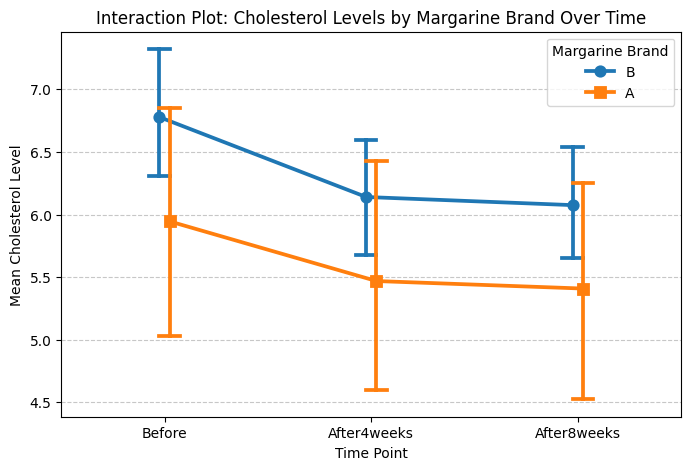

In [ ]:
# 1. Install pingouin (Colab doesn't have it by default)
!pip install pingouin

import pandas as pd
import pingouin as pg
import seaborn as sns
import matplotlib.pyplot as plt

# 2. Load the dataset
# Make sure the file is uploaded to the Colab files panel
df = pd.read_csv('Cholesterol_R2.csv')

# 3. Reshape the data from "Wide" to "Long" format
# Statistical software requires time points to be grouped in a single column
df_long = pd.melt(df,
                  id_vars=['ID', 'Margarine'],
                  value_vars=['Before', 'After4weeks', 'After8weeks'],
                  var_name='Time',
                  value_name='Cholesterol')

# Ensure 'Time' is in chronological order for accurate graphing
df_long['Time'] = pd.Categorical(df_long['Time'],
                                 categories=['Before', 'After4weeks', 'After8weeks'],
                                 ordered=True)

# 4. Perform the Two-Way Mixed ANOVA
# dv = dependent variable, within = time factor, between = group factor
aov = pg.mixed_anova(dv='Cholesterol',
                     within='Time',
                     between='Margarine',
                     subject='ID',
                     data=df_long)

print("=== Two-Way Mixed ANOVA Results ===")
print(aov.to_string())
print("\n")

# 5. Generate Interaction Plot
plt.figure(figsize=(8, 5))
sns.pointplot(data=df_long, x='Time', y='Cholesterol', hue='Margarine',
              dodge=True, markers=['o', 's'], capsize=.1, errorbar='ci')

plt.title('Interaction Plot: Cholesterol Levels by Margarine Brand Over Time')
plt.ylabel('Mean Cholesterol Level')
plt.xlabel('Time Point')
plt.legend(title='Margarine Brand')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()